In [1]:
import torch
import os.path
import argparse
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from utils import *
from PIL import Image
from datetime import datetime
from sklearn.mixture import GaussianMixture as GMM
from sklearn.model_selection import train_test_split

# 1. Set the hyperparameters of the training

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=100, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=10, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=200, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

# 2. Load data

In [3]:
xtrain, ipVec_dim, nChannels = get_mmcelebahq_dataloader(args=opt)

print(ipVec_dim)

/Users/arthurclarysse/Desktop/🎓/03 Masterproef CS/VUB-MT-Development/Models/GenRKM-MMCelebAHQ/utils.py:169: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4424.)
  label = torch.tensor(label, dtype=torch.double).T


65536


In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [5]:
# Define and compute Kernel Matrices, using equation 3 in paper
# This function takes the encoder outputs from two views (X and Y), builds a centered kernel matrix combining both, and then performs kernel PCA to extract the latent variables h and their variances s**.

# def kPCA(X, Y):
#     a = torch.mm(X, torch.t(X)) + torch.mm(Y, torch.t(Y)) # K = \Phi_X \Phi_X^\top + \Phi_Y \Phi_Y^\top
#     nh1 = a.size(0)
#     oneN = torch.div(torch.ones(nh1, nh1), nh1).double().to(opt.device)
#     a = a - torch.mm(oneN, a) - torch.mm(a, oneN) + torch.mm(torch.mm(oneN, a), oneN)  # centering

#     # print("a dtype/device:", a.dtype, a.device)
#     # print("a min/max:", a.min().item(), a.max().item())
#     # print("has NaN:", torch.isnan(a).any().item(), "has Inf:", torch.isinf(a).any().item())
#     # print("symmetry error:", (a - a.T).abs().max().item())

#     h, s, _ = torch.svd(a, some=False) # Eigendecomposition
#     return h[:, :opt.h_dim], s # Select h_dim principal components in h and their eigenvalues in s

def kPCA(X, Y, eps=1e-6):
    # Kernel matrix
    a = X @ X.T + Y @ Y.T  # (B,B)
    B = a.size(0)

    # Centering (same dtype/device as a)
    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    # Force symmetry (numerical)
    a = 0.5 * (a + a.T)

    # Add small jitter to diagonal for conditioning
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    # Eigen-decomposition (ascending eigenvalues)
    evals, evecs = torch.linalg.eigh(a)

    # Sort descending
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Return top components
    h = evecs[:, :opt.h_dim]
    s = evals  # (B,)
    return h, s

In [6]:
# Energy function
def rkm_loss(output1, X, output2, Y):
    # print("output1:", output1.shape, output1.dim(), output1.dtype, output1.device)
    # print("output2:", output2.shape, output2.dim(), output2.dtype, output2.device)

    h, s = kPCA(output1, output2)                   #? 3 - 4: Solve eigendecomposition & select first s principal components
                                                    #?          h = Latent representations, s = Variances (eigenvalues) along those axes

    U = torch.mm(torch.t(output1), h)               #? 10:    𝜙-hat-1(x) ← h using eqaution 5 from paper
    V = torch.mm(torch.t(output2), h)               #? 10:    𝜙-hat-2(y) ← h using eqaution 5 from paper
                                                    #! U = 𝜙1(x)^T h, V = 𝜙2(y)^T h

    x_tilde = net3(torch.mm(h, torch.t(U)))         
    y_tilde = net4(torch.mm(h, torch.t(V)))

    # Costs
    f1 = torch.trace(torch.mm(torch.mm(output1, U), torch.t(h))) + torch.trace(torch.mm(torch.mm(output2, V), torch.t(h)))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:opt.h_dim]), torch.t(h))))
    f3 = 0.5 * ((torch.trace(torch.mm(torch.t(U), U))) + (torch.trace(torch.mm(torch.t(V), V))))

    recon_loss = torch.nn.MSELoss() # Means Squered Error
    f4 = recon_loss(x_tilde.view(-1, ipVec_dim), X.view(-1, ipVec_dim)) + recon_loss(y_tilde.view(-1, 40), Y.view(-1, 40))  # reconstruction loss between X↔︎X_tilde and Y↔︎Y_tilde

    loss = - f1 + f3 + f2 + 0.5 * (- f1 + f3 + f2) ** 2 + opt.c_accu * f4  # stabilized loss
    return loss

In [7]:
# Initialize Feature/Pre-image maps
net1 = Net1().double().to(opt.device)
net2 = Net2().double().to(opt.device)
net3 = Net3().double().to(opt.device)
net4 = Net4().double().to(opt.device)

In [8]:
params = list(net1.parameters()) + list(net3.parameters()) + list(net2.parameters()) + list(net4.parameters())
optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=0)

In [9]:
l_cost = 6  # Costs from where checkpoints will be saved
t = 1
cost = np.inf  # Initialize cost
start = datetime.now()

while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
    avg_loss = 0
    
    for i, (datax, datay) in enumerate(xtrain):
        if i < math.ceil(opt.N / opt.mb_size):
            datax, datay = datax.to(opt.device), datay.to(opt.device)   #? 7:      {x, y} ← {Get mini-batch}
            output1 = net1(datax)                                       #? 8:      𝜙1(x) ← x     // Get embeddings
            output2 = net2(datay)                                       #? 8:      𝜙y(y) ← y     // Get embeddings
            loss = rkm_loss(output1, datax, output2, datay)             #? 9 - 12: See rkm_loss function

            # Update weights of the networks
            optimizer.zero_grad()   # Reset to old gradients
            loss.backward()         # Compute new gradients
            optimizer.step()        # Update weights
            avg_loss += loss.detach().cpu().numpy()
        else:
            break
    cost = avg_loss

    # Remember lowest cost and save checkpoint
    is_best = cost < l_cost
    l_cost = min(cost, l_cost)

    dirs.save_checkpoint({
        'epochs': t + 1,
        'net1_state_dict': net1.state_dict(),
        'net3_state_dict': net3.state_dict(),
        'net2_state_dict': net2.state_dict(),
        'net4_state_dict': net4.state_dict(),
        'l_cost': l_cost,
        'optimizer': optimizer.state_dict()}, is_best)
    print(t, cost)
    t += 1
print('Finished Training in: {}. Lowest cost: {}'.format(str(datetime.now() - start), l_cost))

if os.path.exists('cp/{}'.format(dirs.dircp)):
    sd_mdl = torch.load('cp/{}'.format(dirs.dircp))
    net1.load_state_dict(sd_mdl['net1_state_dict'])
    net3.load_state_dict(sd_mdl['net3_state_dict'])
    net2.load_state_dict(sd_mdl['net2_state_dict'])
    net4.load_state_dict(sd_mdl['net4_state_dict'])

U, V, h, s = mmcelebahq_final_compute(opt, net1, net2, kPCA)

1 50.55848478582519
2 50.51739306147956
3 50.47477743918551
4 50.43116356854543
5 50.38687912856417
6 50.341161987113296
7 50.29343376093774
8 50.24377705480819
9 50.19169601174046
10 50.13563328657304
11 50.07456388892496
12 50.0074056872502
13 49.932514633814456
14 49.84883873545947
15 49.74961438813423
16 49.6233885806703
17 49.45600162114905
18 49.22979307265
19 48.9236324653916
20 48.50179583694174
21 47.92056732508619
22 47.12864567286457
23 46.10180718994045
24 44.83830667381054
25 43.378776010076855
26 41.855458328458546
27 40.43292632015613
28 39.21457186527754
29 38.20911955239157
30 37.39815743636744
31 36.811426169937846
32 36.509111669210206
33 36.42508492361313
34 36.426462291780325
35 36.441039824507435
36 36.446364161107105
37 36.44056518374924
38 36.42757240991724
39 36.41165043728215
40 36.39549991570193
41 36.38027134429124
42 36.36630992621764
43 36.35360907732396
44 36.34195643333134
45 36.3310579840619
46 36.32097506262534
47 36.31128283410261
48 36.30195646846951

In [10]:
# Save Model =============
# torch.save({'net1': net1,
#             'net3': net3,
#             'net2': net2,
#             'net4': net4,
#             'net1_state_dict': net1.state_dict(),
#             'net3_state_dict': net3.state_dict(),
#             'net2_state_dict': net2.state_dict(),
#             'net4_state_dict': net4.state_dict(),
#             'h': h,
#             'opt': opt, 's': s, 'U': U, 'V': V}, 'out/{}'.form.at(dirs.dirout))

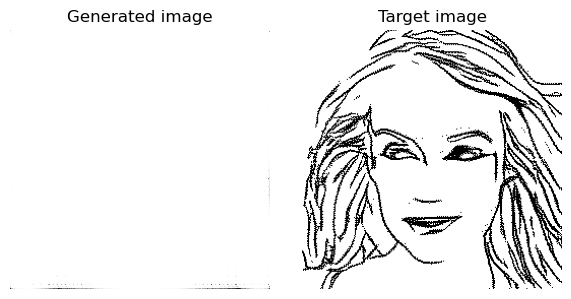

Generated label (one-hot):  [0.49445963 0.5171172  0.51614258 0.48478584 0.46701235 0.4450122
 0.47327688 0.50496563 0.54647547 0.48754417 0.50924825 0.45428283
 0.46187495 0.48833052 0.44862334 0.51000788 0.4476864  0.52658866
 0.56561695 0.55465653 0.45554759 0.55176394 0.47083795 0.46489678
 0.54383055 0.48553208 0.56562571 0.45964898 0.50348    0.4764821
 0.4752622  0.55368056 0.46243595 0.54385392 0.55745347 0.46183674
 0.48306506 0.47181306 0.55530009 0.49905161]


In [11]:
target_index = 1

h_target = h[target_index, :]
# make tensor [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  
# h_target = torch.zeros(opt.h_dim).double().to(opt.device)
# h_target[1] = 1.0

# x_gen = net3(torch.mv(U, h_target)).detach().cpu().numpy().reshape(28, 28)
z = torch.mv(U, h_target)          # [z_dim]
z = z.unsqueeze(0)                 # [1, z_dim]  <-- add batch dim

x_gen = net3(z).detach().cpu().numpy()
x_gen = x_gen.reshape(256, 256)      # if output is flat 784

y_gen = net4(torch.mv(V, h_target)).detach().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].imshow(x_gen, cmap='gray')
ax[0].set_title('Generated image')
ax[0].axis('off')

ax[1].imshow(xtrain.dataset[target_index][0][0], cmap='gray')
ax[1].set_title('Target image')
ax[1].axis('off')

plt.tight_layout()
plt.show()

print('Generated label (one-hot): ', y_gen)